# Lab 07: Open Ended 

### **Student Information**
- **Name**: Abdul Hayy Khan
- **Roll No**: 24F-AI-051

### Project: 1. Employee Attrition Analyzer

Analyze a dataset of employee records to predict whether an employee is likely to leave the company.

Dataset: [IBM HR Analytics Employee Attrition & Performance](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)

Clean and preprocess categorical and numerical data.

In [18]:
# import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


In [19]:
# load dataset

df = pd.read_csv("datasets/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print("First 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionL

In [20]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check duplicates
print("\nDuplicates after cleaning:")
print(df.duplicated().sum())


Duplicates after cleaning:
0


In [21]:
# remove unnecessary columns

columns_to_drop = [
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
]

df = df.drop(columns=columns_to_drop)

print("\nColumns after removing unnecessary columns:")
print(df.columns)


Columns after removing unnecessary columns:
Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [22]:
# encode target variable

df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

print("\nTarget values:")
print(df["Attrition"].value_counts())


Target values:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [23]:
# encode categorical variables

categorical_columns = df.select_dtypes(
    include=["object"]
).columns

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("\nData after encoding:")
print(df.head())


Data after encoding:
   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   
1   49          0        279                 8          1   
2   37          1       1373                 2          2   
3   33          0       1392                 3          4   
4   27          0        591                 2          1   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   
1                        3          61               2         2   
2                        4          92               2         1   
3                        4          56               3         1   
4                        1          40               3         1   

   JobSatisfaction  ...  JobRole_Laboratory Technician  JobRole_Manager  \
0                4  ...                          False            False   
1                2  ...                          Fal

In [24]:
# check data

print("\nMissing values:")
print(df.isnull().sum())

print("\nFinal shape:")
print(df.shape)


Missing values:
Age                                  0
Attrition                            0
DailyRate                            0
DistanceFromHome                     0
Education                            0
EnvironmentSatisfaction              0
HourlyRate                           0
JobInvolvement                       0
JobLevel                             0
JobSatisfaction                      0
MonthlyIncome                        0
MonthlyRate                          0
NumCompaniesWorked                   0
PercentSalaryHike                    0
PerformanceRating                    0
RelationshipSatisfaction             0
StockOptionLevel                     0
TotalWorkingYears                    0
TrainingTimesLastYear                0
WorkLifeBalance                      0
YearsAtCompany                       0
YearsInCurrentRole                   0
YearsSinceLastPromotion              0
YearsWithCurrManager                 0
BusinessTravel_Travel_Frequently     0
Business

In [25]:
# separate features and target variable

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

Train and compare Logistic Regression, Decision Tree, and Random Forest models.

In [26]:
# train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (1176, 44)
Testing data: (294, 44)


In [27]:
# feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
# model 1: logistic regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

In [29]:
# model 2: descision tree 

decision_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

tree_pred = decision_tree.predict(
    X_test
)


In [30]:
# model 3: random forest

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(
    X_train,
    y_train
)

forest_pred = random_forest.predict(
    X_test
)

Evaluate results using confusion matrix, F1 score, and feature importance visualization.

In [31]:
# model evaluation function 

def evaluate_model(name, y_test, y_pred):

    print("\n" + name)
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            zero_division=0
        )
    )

    return accuracy, precision, recall, f1

In [32]:
# evaluate all three models

logistic_results = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred
)

tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred
)

forest_results = evaluate_model(
    "Random Forest",
    y_test,
    forest_pred
)


Logistic Regression
Accuracy : 0.8605442176870748
Precision: 0.6153846153846154
Recall   : 0.3404255319148936
F1 Score : 0.4383561643835616

Confusion Matrix:
[[237  10]
 [ 31  16]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294


Decision Tree
Accuracy : 0.8333333333333334
Precision: 0.4444444444444444
Recall   : 0.1702127659574468
F1 Score : 0.24615384615384617

Confusion Matrix:
[[237  10]
 [ 39   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       247
           1       0.44      0.17      0.25        47

    accuracy                           0.83       294
   macro avg       0.65      0.56      0.58   

In [33]:
# model comparison

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        logistic_results[0],
        tree_results[0],
        forest_results[0]
    ],

    "Precision": [
        logistic_results[1],
        tree_results[1],
        forest_results[1]
    ],

    "Recall": [
        logistic_results[2],
        tree_results[2],
        forest_results[2]
    ],

    "F1 Score": [
        logistic_results[3],
        tree_results[3],
        forest_results[3]
    ]
})

print("MODEL COMPARISON")

print(results)


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.860544   0.615385  0.340426  0.438356
1        Decision Tree  0.833333   0.444444  0.170213  0.246154
2        Random Forest  0.833333   0.416667  0.106383  0.169492


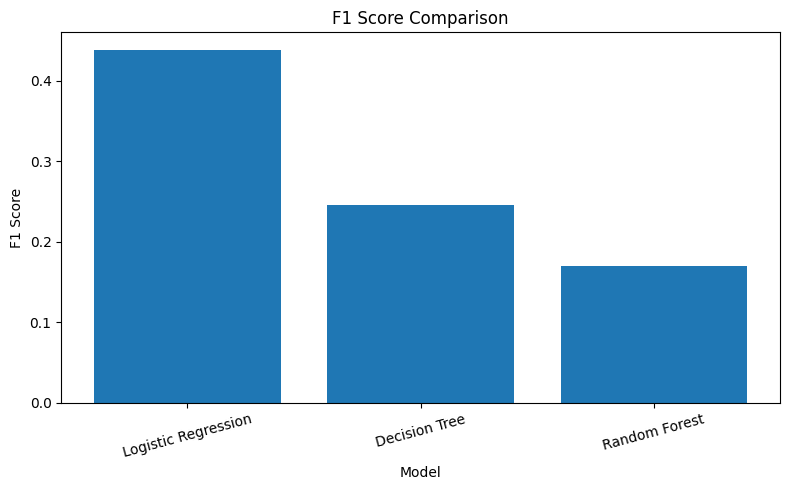

In [34]:
# F1 score comparison

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["F1 Score"]
)

plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison")

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


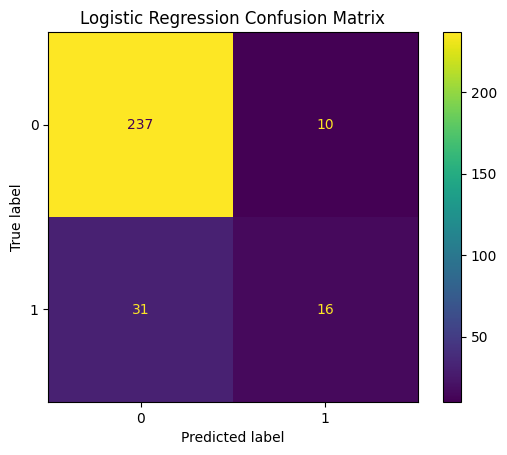

In [35]:
# confusion matrix for logistic regression

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_pred
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()


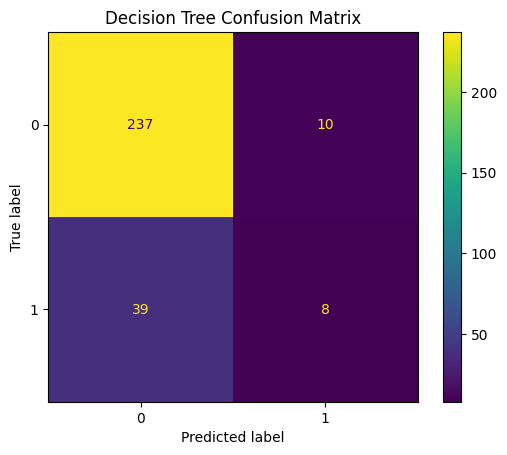

In [36]:
# confusion matrix for decision tree

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_pred
)

plt.title("Decision Tree Confusion Matrix")
plt.show()


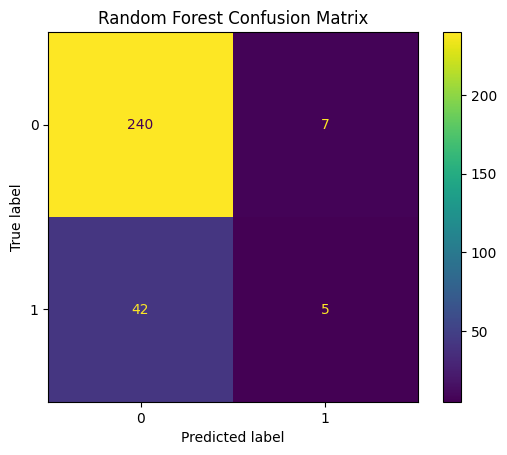

In [37]:
# confusion matrix for random forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()


In [38]:
# random forest feature importance

importance = random_forest.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("TOP IMPORTANT FEATURES")

print(
    feature_importance.head(15)
)


TOP IMPORTANT FEATURES
                    Feature  Importance
9             MonthlyIncome    0.072306
0                       Age    0.072260
16        TotalWorkingYears    0.053589
1                 DailyRate    0.051670
5                HourlyRate    0.047866
2          DistanceFromHome    0.047793
10              MonthlyRate    0.047228
19           YearsAtCompany    0.044137
43             OverTime_Yes    0.037830
22     YearsWithCurrManager    0.035452
11       NumCompaniesWorked    0.035212
12        PercentSalaryHike    0.033997
4   EnvironmentSatisfaction    0.027282
17    TrainingTimesLastYear    0.026506
20       YearsInCurrentRole    0.026050


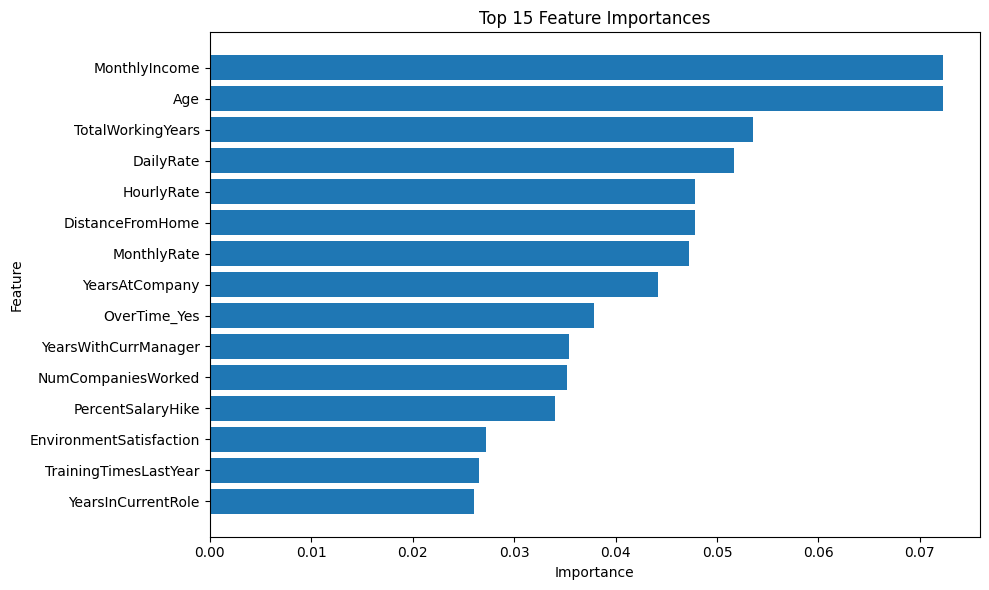

In [39]:
# feature importance visualization

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


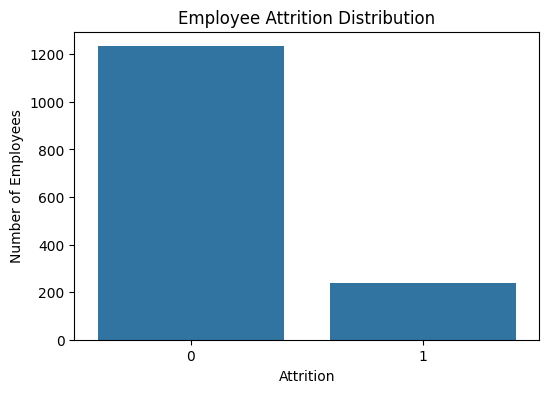

In [40]:
# attrition distribution

plt.figure(figsize=(6, 4))

sns.countplot(
    x=df["Attrition"]
)

plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.title("Employee Attrition Distribution")

plt.show()


In [41]:
# final result

best_model = results.loc[
    results["F1 Score"].idxmax(),
    "Model"
]

best_f1 = results["F1 Score"].max()

print("FINAL RESULT")

print("Best Model:", best_model)
print("Best F1 Score:", best_f1)

FINAL RESULT
Best Model: Logistic Regression
Best F1 Score: 0.4383561643835616
